In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the path to your data
file_path = os.path.join('..', 'data', 'kenya.csv')

# Load and prepare the date index
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')
df.set_index('Date', inplace=True)

# Preview the data
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
Date,,,,,,,,,,,,
2015-01-01,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
2015-01-02,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2015-01-03,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
2015-01-04,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
2015-01-05,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [10]:
# Check for missing values
print("Missing Values Check - Kenya:")
print(df.isnull().sum())

# Statistical Summary
print("\nStatistical Summary - Kenya:")
display(df.describe())

Missing Values Check - Kenya:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

Statistical Summary - Kenya:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000


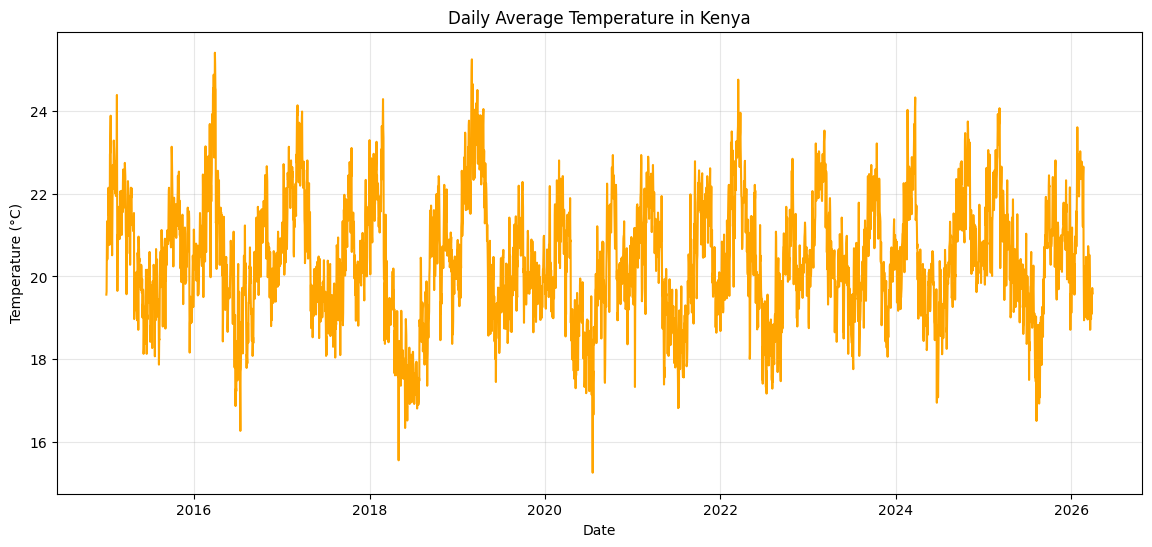

In [11]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='T2M', color='orange')
plt.title('Daily Average Temperature in Kenya')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

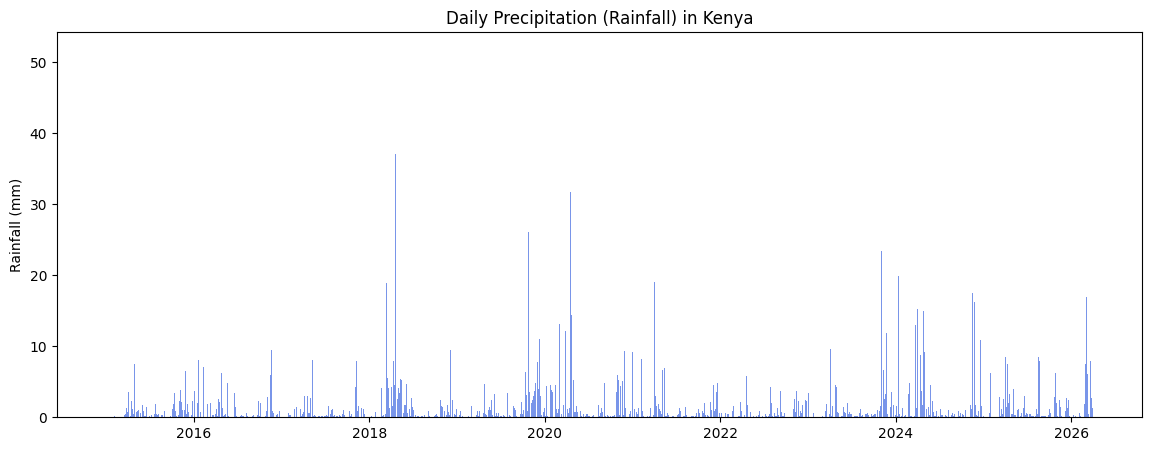

In [12]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['PRECTOTCORR'], color='royalblue', alpha=0.7)
plt.title('Daily Precipitation (Rainfall) in Kenya')
plt.ylabel('Rainfall (mm)')
plt.show()

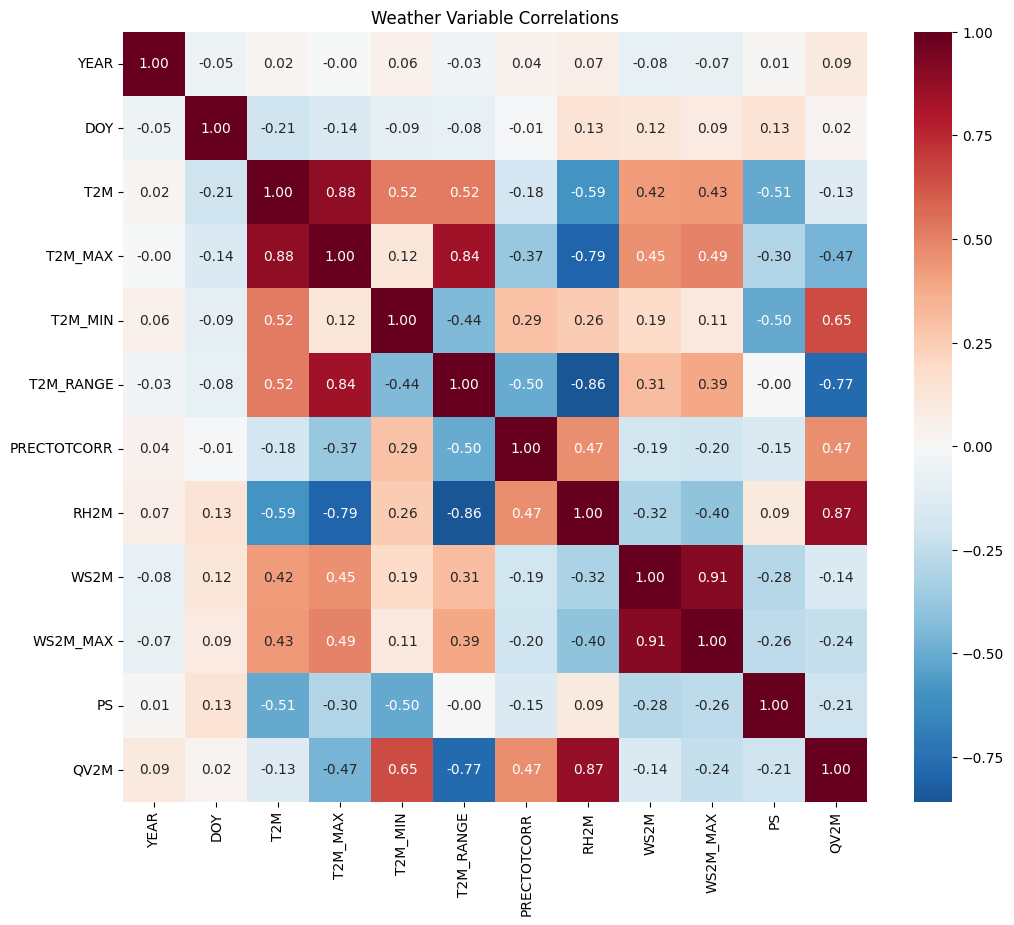

In [13]:
plt.figure(figsize=(12, 10))
# We calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Weather Variable Correlations')
plt.show()

In [14]:
import numpy as np
from scipy import stats

# 1. Load and add Country column
df = pd.read_csv('../data/kenya.csv')
df['Country'] = 'Kenya'

# 2. Convert YEAR/DOY to Date and extract Month
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df.set_index('Date', inplace=True)

# 3. Handle NASA Sentinel values (-999)
df.replace(-999, np.nan, inplace=True)

# 4. Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")
df.drop_duplicates(inplace=True)

# 5. Missing value report
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_pct)

Duplicates found: 0

Missing Values Percentage:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Month          0.0
dtype: float64


In [15]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))

# Flagging rows where Z > 3
outliers = (z_scores > 3).all(axis=1)
print(f"Number of outlier rows flagged in Kenya: {outliers.sum()}")

# Decision: We will retain them for now as weather extremes (like heavy rain) 
# are important for climate study, but we acknowledge them.

Number of outlier rows flagged in Kenya: 0


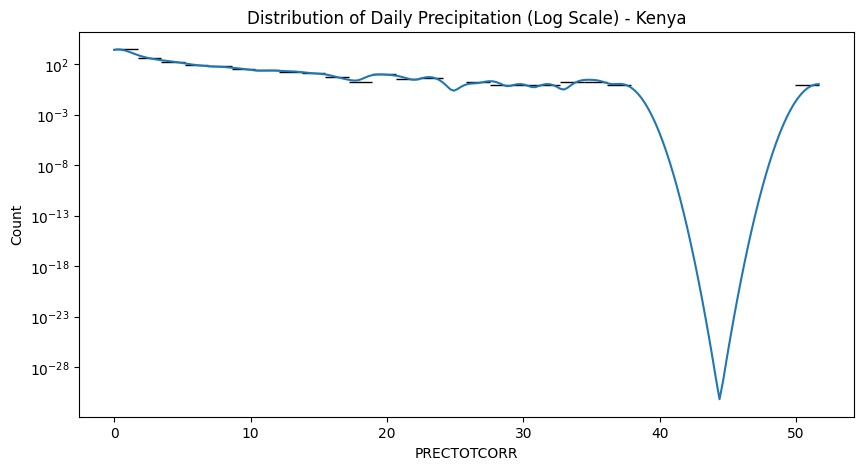

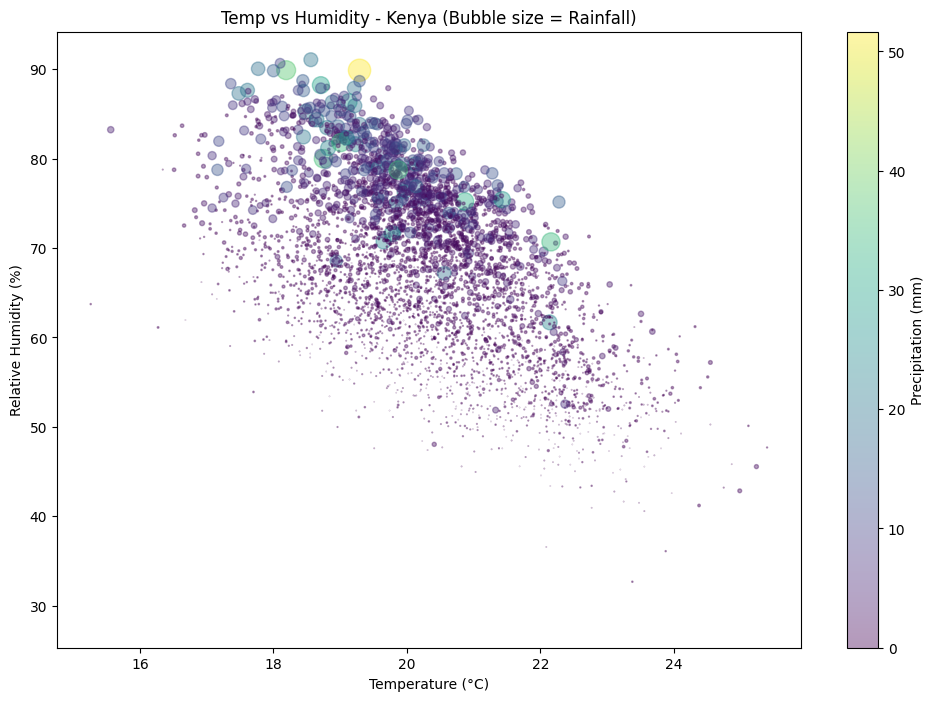

In [16]:
# Histogram of Rainfall (Log scale)
plt.figure(figsize=(10, 5))
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale) - Kenya')
plt.show()

# Bubble Chart: Temp vs Humidity (Size = Rain)
plt.figure(figsize=(12, 8))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.4, c=df['PRECTOTCORR'], cmap='viridis')
plt.colorbar(label='Precipitation (mm)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temp vs Humidity - Kenya (Bubble size = Rainfall)')
plt.show()

In [17]:
# Create the directory if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Export
df.to_csv('../data/kenya_clean.csv')
print("Cleaned data exported to data/kenya_clean.csv")

Cleaned data exported to data/kenya_clean.csv


Final Analysis: 
Kenya Climate Trends
The Trend: The temperature in Kenya shows a stable, seasonal bimodal pattern (two peaks per year). The average temperature revolves around 20.4°C, with maximums reaching 34.3°C. Looking at the multi-year data, the oscillations remain consistent, suggesting that while the climate is warm, there hasn't been a drastic shift in the baseline temperature in this dataset.

The Connection: For Kenya, Relative Humidity (RH2M) is a major driver of precipitation, with a positive correlation of 0.47. The Heatmap also reveals a strong negative correlation (-0.86) between Humidity and Temperature Range, suggesting that rainy, humid days significantly stabilize the daily temperature spread.

The Outliers: The Z-score test flagged 0 rows for simultaneous multi-variable extremes. However, the data shows rainfall peaks up to 51.65mm, which are significantly higher than the daily mean of 1.47mm. These specific rainfall events are kept in the dataset as they are vital for studying agricultural cycles and water management in the region.